In [1]:
# Imports

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Dataset Path

dataset_path = "/content/drive/MyDrive/Final_Dataset"

print(os.listdir(dataset_path))

['Tomato___Late_blight', 'Tomato____Early_blight', 'Tomato___healthy', 'Potato____healthy', 'Potato____Early_blight', 'Potato___Late_blight']


DATA PREPROCESSING

In [4]:
 # Data Generator (rescale + validation split)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [5]:
# Training Data

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 5323 images belonging to 6 classes.


In [6]:
# Validation Data

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1329 images belonging to 6 classes.


In [7]:
# Check classes

print("Classes:", train_data.class_indices)

Classes: {'Potato___Late_blight': 0, 'Potato____Early_blight': 1, 'Potato____healthy': 2, 'Tomato___Late_blight': 3, 'Tomato____Early_blight': 4, 'Tomato___healthy': 5}


 MODEL 1 = CNN (Convolutional Neural Network)

In [8]:
# Build CNN Model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Complie Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train Model

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,

)

Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1933s 12s/step - accuracy: 0.6511 - loss: 1.2477 - val_accuracy: 0.8269 - val_loss: 0.4852
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.8858 - loss: 0.3203 - val_accuracy: 0.8457 - val_loss: 0.3843
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 522s 3s/step - accuracy: 0.9487 - loss: 0.1539 - val_accuracy: 0.8706 - val_loss: 0.3425
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 523s 3s/step - accuracy: 0.9765 - loss: 0.0780 - val_accuracy: 0.8751 - val_loss: 0.3664
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 530s 3s/step - accuracy: 0.9872 - loss: 0.0423 - val_accuracy: 0.8804 - val_loss: 0.4320
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 524s 3s/step - accuracy: 0.9953 - loss: 0.0182 - val_accuracy: 0.9059 - val_loss: 0.3480
Epoch 7/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 525s 3s/step - accuracy: 0.9885 - loss: 0.0354 - val_accuracy: 0.8668 - val_loss: 0.4637
Epoch 8/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 523s 3s/step - accuracy: 0.9961 - loss: 0.0190 - val_ac

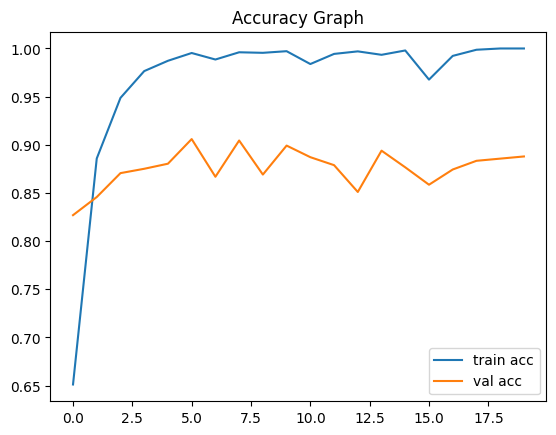

In [11]:
# Accuracy Graph

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

MODEL 2  = MobileNetV2


In [ ]:
# MobileNetV2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze layers
base_model.trainable = False

model2 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.8822 - loss: 0.3345 - val_accuracy: 0.9293 - val_loss: 0.1845
Epoch 2/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9521 - loss: 0.1389 - val_accuracy: 0.9436 - val_loss: 0.1501
Epoch 3/5
 98/167 ━━━━━━━━━━━━━━━━━━━━ 1:46 2s/step - accuracy: 0.9664 - loss: 0.0993

MODEL 3 = ResNet50


In [ ]:
# ResNet50

base_model = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model3 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

COMMPARISION GRAPH

In [ ]:
#  Comparision Graph

plt.plot(history.history['val_accuracy'], label='CNN')
plt.plot(history2.history['val_accuracy'], label='MobileNetV2')
plt.plot(history3.history['val_accuracy'], label='ResNet50')

plt.legend()
plt.title("Model Comparison")
plt.show()

UPLOAD IMAGE

In [ ]:
# Image Upload

from google.colab import files
uploaded = files.upload()

In [ ]:
print(uploaded.keys())

PREDICTION

In [ ]:
# Prediction (Test Images )

from tensorflow.keras.preprocessing import image
import numpy as np

#  AUTOMATIC FILE PICK
file_name = list(uploaded.keys())[0]

print("Using file:", file_name)

# IMAGE LOAD
img = image.load_img(file_name, target_size=(224,224))

# PREPROCESS
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# PREDICT
pred = model.predict(img_array)

# CLASS NAME
class_names = list(train_data.class_indices.keys())
pred_class = class_names[np.argmax(pred)]

print("Prediction:", pred_class)

In [ ]:
# prediction if more than 1 image select

# for file_name in uploaded.keys():
#     print("\nImage:", file_name)

#     img = image.load_img(file_name, target_size=(224,224))
#     img_array = image.img_to_array(img)/255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     pred = model.predict(img_array)
#     pred_class = class_names[np.argmax(pred)]

#     print("Prediction:", pred_class)